# SAM RTN Quantization Analysis

This notebook provides a comprehensive analysis of RTN (Round-to-Nearest) quantization for SAM models, focusing on MSE measurement across attention layers.


In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2" 

from observers import (
    image_encoder_observer_patch, 
    ImageEncoderViTObserver
) 
from utils.utils import get_activation_boxplot, to_numpy,  inference_image
from segment_anything import SamPredictor, sam_model_registry
import matplotlib.pyplot as plt

from segment_anything.modeling.image_encoder import (
    Attention,
    Block,
    ImageEncoderViT,
)

from segment_anything.modeling.image_encoder import (
    window_partition,
    window_unpartition,
)
from segment_anything.modeling.image_encoder import add_decomposed_rel_pos

In [5]:

model_type = "vit_l"
num_calib_samples = 1
checkpoint_path = "./ckts/sam_hq_vit_l.pth"

# Initialize model and predictor
sam = sam_model_registry[model_type](checkpoint=checkpoint_path).to("cuda")
predictor = SamPredictor(sam)

image_encoder_observer_patch(
    predictor.model,
    processor=None,
    n_bits=8,
    weight_quant="per_channel",
    act_quant="per_token",
)

<All keys matched successfully>


TypeError: image_encoder_observer_patch() got an unexpected keyword argument 'processor'

(1000, 894, 3)


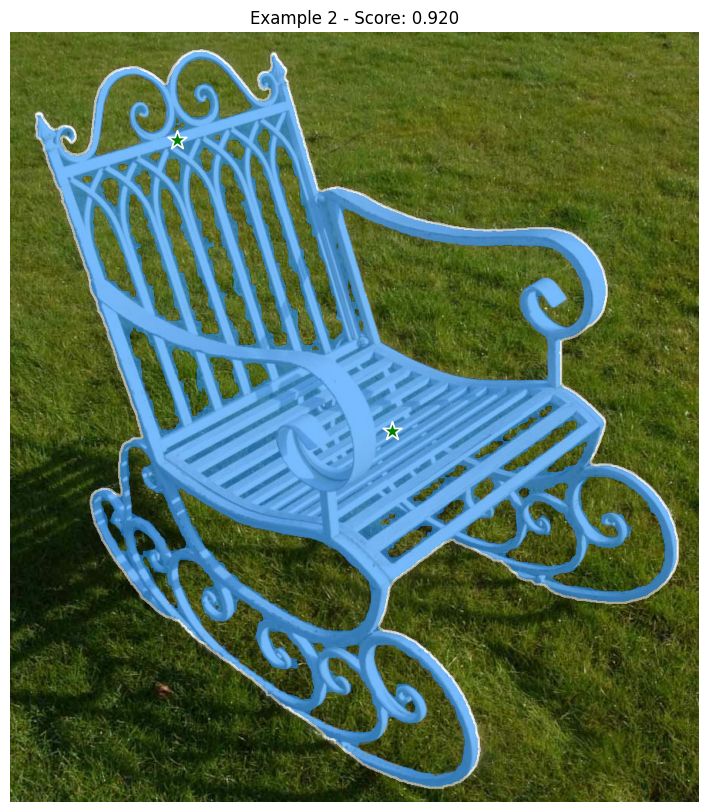

(array([[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]]),
 array([0.92036456], dtype=float32),
 array([[[ -9.107651 , -11.07209  ,  -9.391892 , ...,  -8.006154 ,
           -9.402494 ,  -8.977163 ],
         [ -9.57795  , -11.841938 ,  -9.07319  , ...,  -8.846717 ,
          -10.100636 , -10.052495 ],
         [ -9.70176  , -11.920888 , -10.31607  , ...,  -8.262246 ,
          -10.772161 , -11.075421 ],
         ...,
         [ -7.8444147, -11.414352 , -10.418554 , ...,  -4.7821593,
           -6.415207 ,  -5.927807 ],
         [ -9.748657 , -11.599485 , -11.158998 , ...,  -5.607768 ,
           -7.2104964,  -6.889926 ],
         [-10.173218 , -11.409474 , -10.611198 , ...,  -5.243769

In [4]:
# results = inference_image(predictor, image_dir='./input_imgs/', example_idx=3, show_image=True)
# for i in range(5):
inference_image(predictor, image_dir='./input_imgs/', example_idx=2, show_image=True)

In [5]:
ImageEncoderViTObserver.attention_score.keys()

dict_keys(['block_0_x', 'block_0_attn', 'block_1_x', 'block_1_attn', 'block_2_x', 'block_2_attn', 'block_3_x', 'block_3_attn', 'block_4_x', 'block_4_attn', 'block_5_x', 'block_5_attn', 'block_6_x', 'block_6_attn', 'block_7_x', 'block_7_attn', 'block_8_x', 'block_8_attn', 'block_9_x', 'block_9_attn', 'block_10_x', 'block_10_attn', 'block_11_x', 'block_11_attn', 'block_12_x', 'block_12_attn', 'block_13_x', 'block_13_attn', 'block_14_x', 'block_14_attn', 'block_15_x', 'block_15_attn', 'block_16_x', 'block_16_attn', 'block_17_x', 'block_17_attn', 'block_18_x', 'block_18_attn', 'block_19_x', 'block_19_attn', 'block_20_x', 'block_20_attn', 'block_21_x', 'block_21_attn', 'block_22_x', 'block_22_attn', 'block_23_x', 'block_23_attn'])

In [6]:

def get_attention_map(layer_idx:int):
    attn = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_attn'][0]
    return attn

# def get_attention_map_mean(layer_idx:int):
#     attn = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_attn_mean'][0]
#     return attn

def get_feature(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_x'][0]
    return x
def get_O(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_O'][0]
    return x
def get_O_qha(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_O_qha'][0]
    return x
def get_O_qfull(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_O_qfull'][0]
    return x
# def get_q(layer_idx:int):
#     x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_q'][0]
#     return x
# def get_k(layer_idx:int):
#     x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_k'][0]
#     return x
# def get_v(layer_idx:int):
#     x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_v'][0]
#     return x

# def get_q_mean(layer_idx:int):
#     x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_q_mean'][0]
#     return x
# def get_v_mean(layer_idx:int):
#     x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_v_mean'][0]
#     return x




0 (400, 196, 196)
1 (400, 196, 196)
2 (400, 196, 196)
3 (400, 196, 196)
4 (400, 196, 196)
5 (16, 4096, 4096)
6 (400, 196, 196)
7 (400, 196, 196)
8 (400, 196, 196)
9 (400, 196, 196)
10 (400, 196, 196)
11 (16, 4096, 4096)
12 (400, 196, 196)
13 (400, 196, 196)
14 (400, 196, 196)
15 (400, 196, 196)
16 (400, 196, 196)
17 (16, 4096, 4096)
18 (400, 196, 196)
19 (400, 196, 196)
20 (400, 196, 196)
21 (400, 196, 196)
22 (400, 196, 196)
23 (16, 4096, 4096)


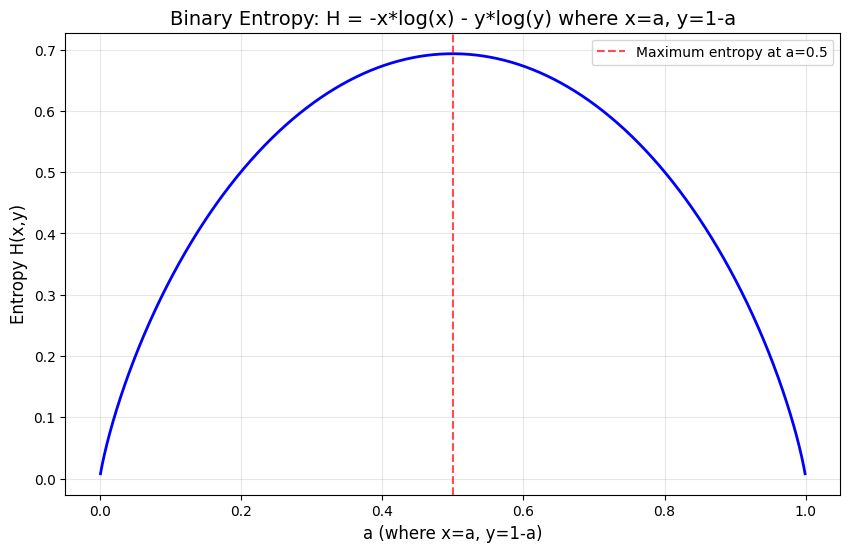

In [29]:
for i in range(24):
        
    attn =  get_attention_map(i)
    print(i,attn.shape)

import torch
import matplotlib.pyplot as plt
import numpy as np

# Create range for a from 0 to 1
a_values = np.linspace(0.001, 0.999, 1000)  # Avoid 0 and 1 to prevent log(0)

# Calculate entropy for binary distribution (x=a, y=1-a)
def binary_entropy(a):
    # For two variables: x=a, y=1-a
    x = a
    y = 1 - a
    
    # Add small epsilon to avoid log(0)
    eps = 1e-12
    x = max(x, eps)
    y = max(y, eps)
    
    # Calculate entropy: H = -x*log(x) - y*log(y)
    entropy = -(x * np.log(x) + y * np.log(y))
    return entropy

# Calculate entropy values
entropy_values = [binary_entropy(a) for a in a_values]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(a_values, entropy_values, 'b-', linewidth=2)
plt.xlabel('a (where x=a, y=1-a)', fontsize=12)
plt.ylabel('Entropy H(x,y)', fontsize=12)
plt.title('Binary Entropy: H = -x*log(x) - y*log(y) where x=a, y=1-a', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.7, label='Maximum entropy at a=0.5')
plt.legend()
plt.show()


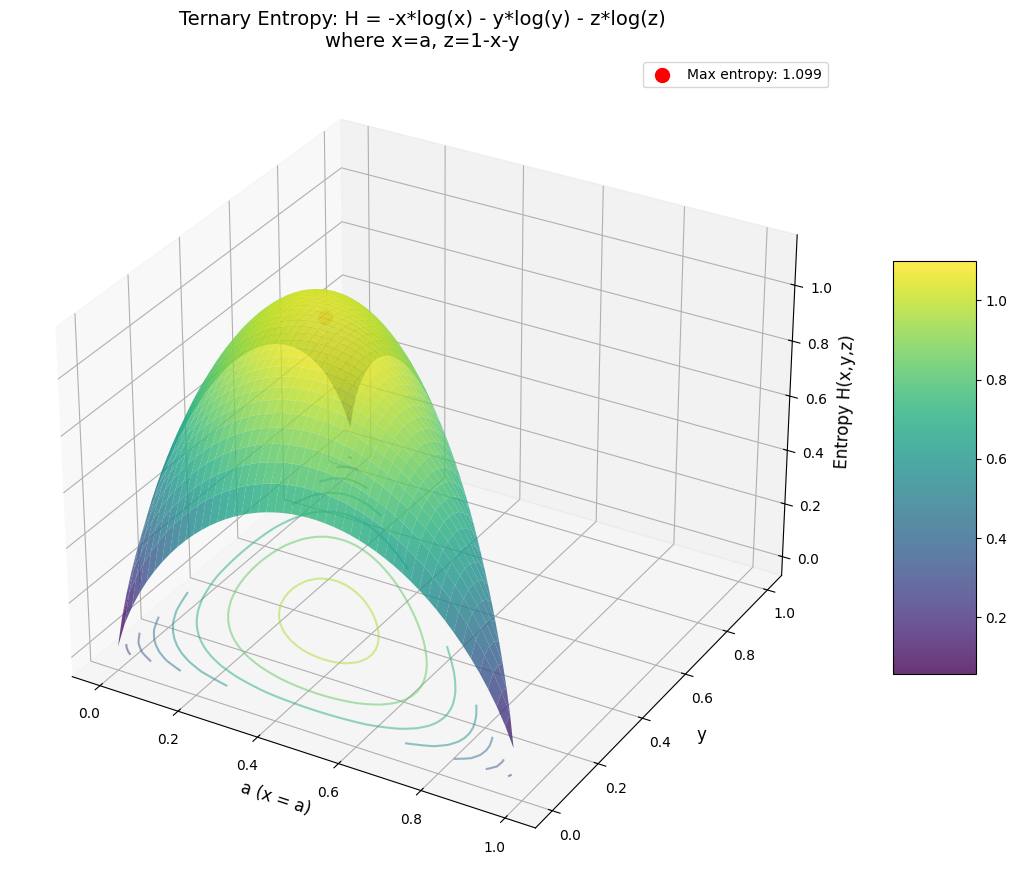

Maximum entropy for 3 variables (uniform): 1.0986
Theoretical maximum: ln(3) = 1.0986


In [31]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Create grid for a and y
a_values = np.linspace(0.001, 0.999, 50)
y_values = np.linspace(0.001, 0.999, 50)

# Create meshgrid
A, Y = np.meshgrid(a_values, y_values)

# Function to calculate entropy for three variables
def ternary_entropy(a, y):
    x = a
    z = 1 - x - y
    
    # Only calculate for valid probability simplex (x,y,z >= 0 and sum = 1)
    if z <= 0 or x <= 0 or y <= 0:
        return np.nan
    
    # Add small epsilon to avoid log(0)
    eps = 1e-12
    x = max(x, eps)
    y = max(y, eps) 
    z = max(z, eps)
    
    # Calculate entropy: H = -x*log(x) - y*log(y) - z*log(z)
    entropy = -(x * np.log(x) + y * np.log(y) + z * np.log(z))
    return entropy

# Calculate entropy values for the grid
Z_entropy = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        a_val = A[i, j]
        y_val = Y[i, j]
        
        # Check if point is in valid simplex (x + y + z = 1, all >= 0)
        if a_val + y_val <= 1:
            Z_entropy[i, j] = ternary_entropy(a_val, y_val)
        else:
            Z_entropy[i, j] = np.nan

# Create 3D plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Remove NaN values for plotting
mask = ~np.isnan(Z_entropy)
surface = ax.plot_surface(A, Y, Z_entropy, cmap='viridis', alpha=0.8)

# Add contour lines at bottom
ax.contour(A, Y, Z_entropy, zdir='z', offset=0, cmap='viridis', alpha=0.5)

# Labels and title
ax.set_xlabel('a (x = a)', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_zlabel('Entropy H(x,y,z)', fontsize=12)
ax.set_title('Ternary Entropy: H = -x*log(x) - y*log(y) - z*log(z)\nwhere x=a, z=1-x-y', fontsize=14)

# Add colorbar
plt.colorbar(surface, shrink=0.5, aspect=5)

# Mark maximum entropy point (uniform distribution: x=y=z=1/3)
max_entropy_point = ternary_entropy(1/3, 1/3)
ax.scatter([1/3], [1/3], [max_entropy_point], color='red', s=100, label=f'Max entropy: {max_entropy_point:.3f}')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Maximum entropy for 3 variables (uniform): {ternary_entropy(1/3, 1/3):.4f}")
print(f"Theoretical maximum: ln(3) = {np.log(3):.4f}")

In [ ]:
def calculate_entropy_variance(attn_head):
    # Convert to tensor if it's a numpy array
    if isinstance(attn_head, np.ndarray):
        attn_head = torch.from_numpy(attn_head)
    
    eps = 1e-12
    attn_normalized = torch.clamp(attn_head, min=eps)
    
    # Calculate entropy for each query position (each row)
    entropy_per_position = -torch.sum(attn_normalized * torch.log(attn_normalized), dim=-1)
    
    # Calculate variance of entropy values across all positions
    entropy_variance = torch.var(entropy_per_position)
    entropy_mean = torch.mean(entropy_per_position)
    return entropy_variance.item(), entropy_mean.item()
attn1= get_attention_map(1)[0]
entropy_variance, entropy_mean = calculate_entropy_variance(attn1)
print(entropy_variance,entropy_mean )


0.19629445672035217 4.886723041534424


In [27]:
# maximum entrop for 196 elements
a= 196*1/196 * torch.log(torch.tensor(196.0))
print(a)

tensor(5.2781)


(400, 196, 196)
0 0.5343417525291443 4.238585472106934
1 0.0651027038693428 4.4226155281066895
2 1.271513819694519 3.5900561809539795
3 0.4335496723651886 4.147458553314209
4 0.49999865889549255 3.965919256210327
5 0.8328889608383179 3.2133431434631348
6 0.7888583540916443 2.3975231647491455
7 0.6015897989273071 3.351835250854492
8 0.2478226125240326 3.4665029048919678
9 0.03162067010998726 4.477457523345947
10 0.6768096089363098 3.261514186859131
11 0.7018867135047913 3.013094902038574
12 0.5032480359077454 4.125354290008545
13 0.5338135957717896 1.8970001935958862
14 0.6932480931282043 4.254138469696045
15 0.5422937273979187 4.149454116821289
16 0.6290196776390076 4.112882614135742
17 0.15481777489185333 4.254611968994141
18 1.014656662940979 3.781360626220703
19 0.5152515172958374 3.746689796447754
20 0.5705543160438538 3.9758715629577637
21 0.8648277521133423 3.1449785232543945
22 0.8263612985610962 2.4125072956085205
23 0.5200089812278748 3.4749441146850586
24 0.35782045125961304 

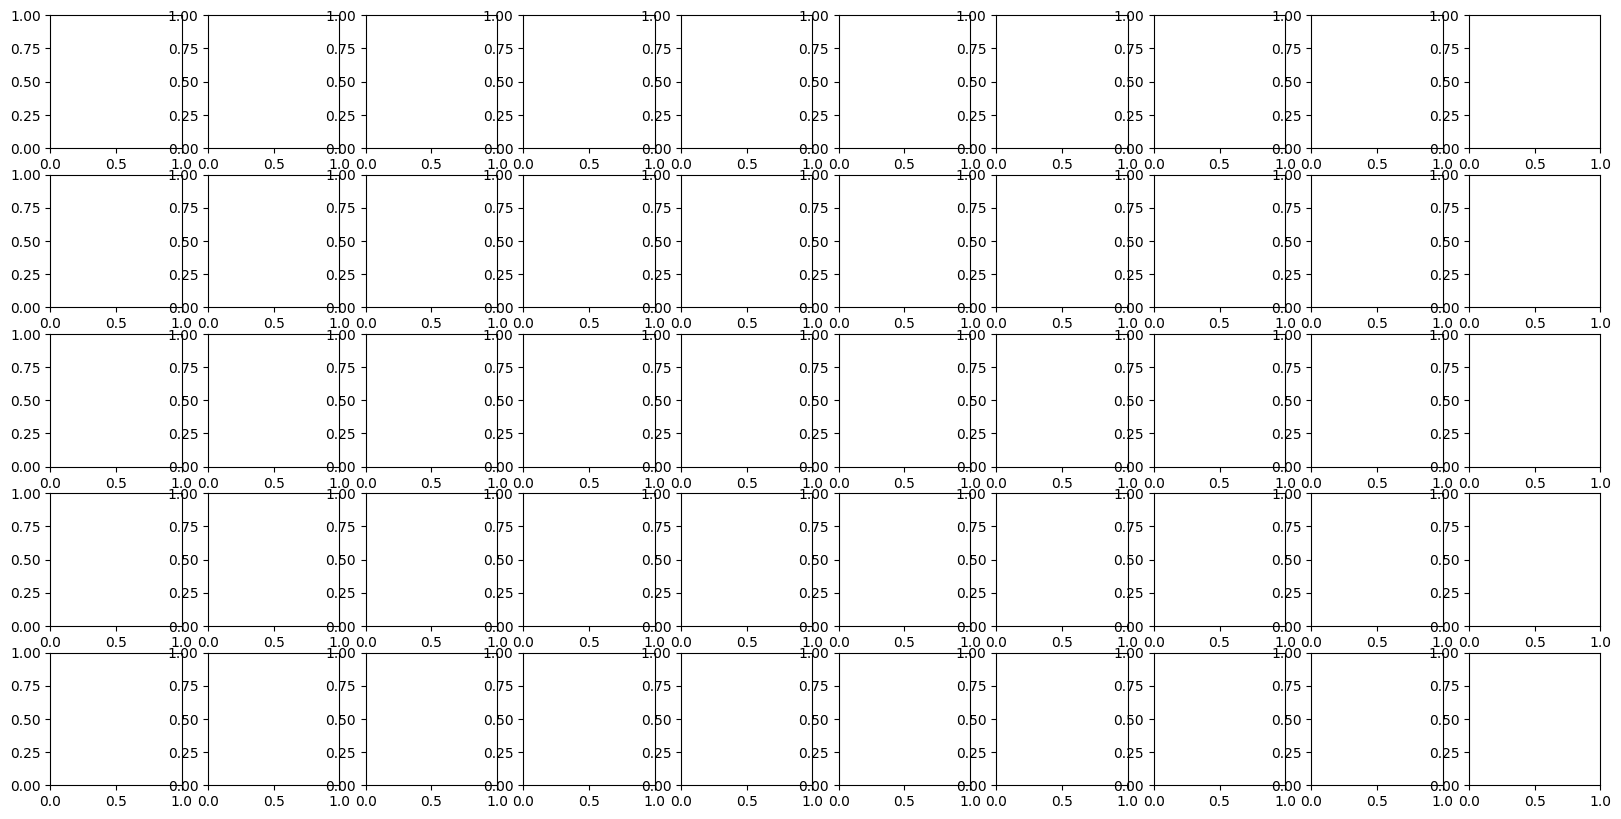

In [28]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot  as plt
import numpy as np

def cal_energy(X:torch.Tensor, margin=0.9):
    """
    Calculate the energy of the input tensor.
    """
    X = F.normalize(X.reshape(-1, X.shape[-1]), dim=-1, p=2)
    score_map = F.elu(X @ X.transpose(-1, -2) - margin)
    scores = score_map.mean(-1)
    return scores

def recal_attn(q, k, v):
    attn = (q * 1/8) @ k.transpose(-2, -1)
    attn = attn.softmax(dim=-1)
    return attn
def calculate_entropy_variance(attn_head):
    # Convert to tensor if it's a numpy array
    if isinstance(attn_head, np.ndarray):
        attn_head = torch.from_numpy(attn_head)
    
    eps = 1e-12
    attn_normalized = torch.clamp(attn_head, min=eps)
    
    # Calculate entropy for each query position (each row)
    entropy_per_position = -torch.sum(attn_normalized * torch.log(attn_normalized), dim=-1)
    
    # Calculate variance of entropy values across all positions
    entropy_variance = torch.var(entropy_per_position)
    entropy_mean = torch.mean(entropy_per_position)
    return entropy_variance.item(), entropy_mean.item()
head_idx = 0
layer_idx = 22
# q = get_q(layer_idx)[head_idx]
# k = get_k(layer_idx)[head_idx]
# v = get_k(layer_idx)[head_idx]

ori_attn = get_attention_map(layer_idx)
# attn_mean = get_attention_map(layer_idx)
print(ori_attn.shape)

# plt.imshow(ori_attn.mean(-1).reshape(64,64))
fig, axes = plt.subplots(5,10,figsize=(20,10))
# for i in range(8):
#     axes[0][i].imshow(ori_attn[2*i].mean(0).reshape(64,64))
#     axes[1][i].imshow(ori_attn[2*i+1].mean(0).reshape(64,64))
# for i in range(10):
#     heads_to_plot = [5*i, 5*i+1, 5*i+2, 5*i+3, 5*i+4]
    
#     for row, head_idx in enumerate(heads_to_plot):
#         attn_head = ori_attn[head_idx]
#         variance, mean = calculate_entropy_variance(attn_head)
#         print(variance, mean)
#         # Plot the attention pattern
#         axes[row][i].imshow(attn_head.mean(0).reshape(14,14))
        
#         # Add entropy metrics as title
#         axes[row][i].set_title(f'Head {head_idx}\nVar: {variance:.3f}\nMean: {mean:.3f}', 
#                               fontsize=8)
#         axes[row][i].axis('off')
for i in range(400):
    attn_head = ori_attn[i]
    variance, mean = calculate_entropy_variance(attn_head)
    print(i, variance, mean)
# print(energy_scores.shape)

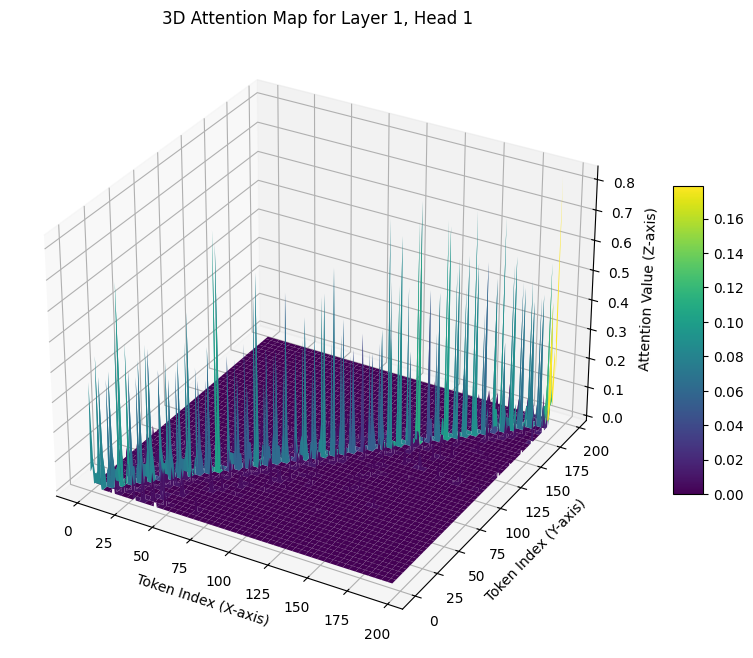

In [13]:
layer_idx = 1  # Replace with your desired layer index
head_idx = 1    # Replace with your desired head index

# Get the attention map for the selected layer
ori_attn = get_attention_map(layer_idx)

# Extract the attention map for the selected head
selected_head_attn = ori_attn[head_idx]  # Shape: (N, N), where N is the number of tokens

# Plot the distribution of all rows
# fig, axes = plt.subplots(8, 8, figsize=(20, 20))  # Adjust grid size as needed
# num_rows = selected_head_attn.shape[0]

# for i in range(min(num_rows, 64)):  # Plot up to 64 rows
#     row_data = selected_head_attn[i]  # Extract the row
#     ax = axes[i // 8, i % 8]  # Determine subplot position
#     ax.hist(row_data, bins=30, alpha=0.7, color='blue',log =True)  # Plot histogram
#     ax.set_title(f"Row {i}")
#     ax.set_xlim(0, 1)  # Adjust x-axis limits if needed
#     ax.set_ylim(0, 50)  # Adjust y-axis limits if needed

# plt.tight_layout()
# plt.show()


# plot 3d attention score
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
num_tokens = selected_head_attn.shape[0]
num_tokensy =num_tokens
x = np.arange(num_tokens)
y = np.arange(num_tokens)
X, Y = np.meshgrid(x, y)

# Convert the attention map to a numpy array for plotting
Z = selected_head_attn[:,:]
# sum = Z.sum(axis=1, keepdims=True)
# print(sum)
# print(len(sum))
# Plot the 3D surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

# Add labels and a color bar
ax.set_title(f"3D Attention Map for Layer {layer_idx}, Head {head_idx}")
ax.set_xlabel("Token Index (X-axis)")
ax.set_ylabel("Token Index (Y-axis)")
ax.set_zlabel("Attention Value (Z-axis)")
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

plt.show()


# ori_attn = get_attention_map(layer_idx)
# ori_attn = get_attention_map(layer_idx)

# # Extract the attention map for the selected head
# selected_head_attn = ori_attn[head_idx]  # Shape: (N, N), where N is the number of tokens

# # Plot the 2D attention map
# plt.figure(figsize=(10, 8))
# plt.imshow(selected_head_attn, cmap='viridis', aspect='auto')

# # Add labels and a color bar
# plt.title(f"2D Attention Map for Layer {layer_idx}, Head {head_idx}")
# plt.xlabel("Token Index (X-axis)")
# plt.ylabel("Token Index (Y-axis)")
# plt.colorbar(label="Attention Value")

# plt.show()

### This if for mean of the map

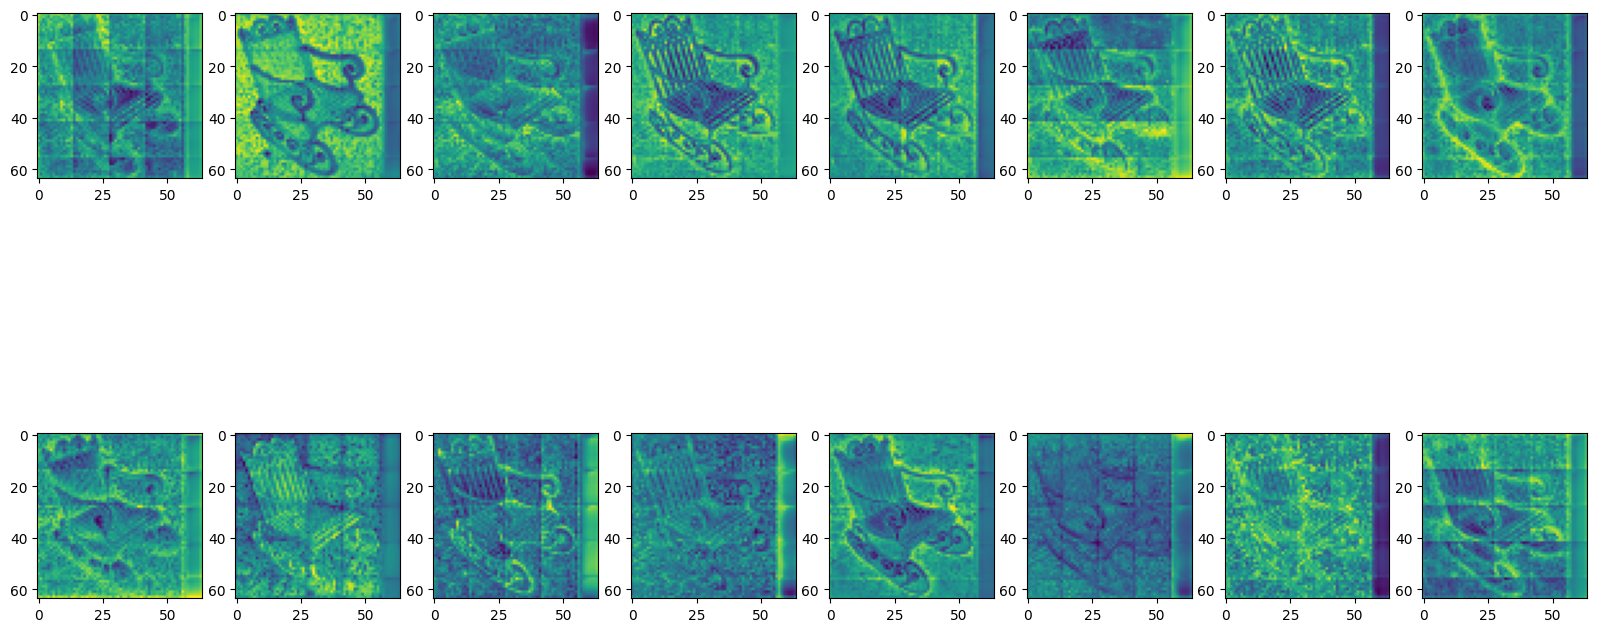

In [ ]:
attn_mean = get_attention_map_mean(layer_idx)


# plt.imshow(ori_attn.mean(-1).reshape(64,64))
fig, axes = plt.subplots(2,8,figsize=(20,10))
for i in range(8):
    axes[0][i].imshow(attn_mean[2*i].mean(0).reshape(64,64))
    axes[1][i].imshow(attn_mean[2*i+1].mean(0).reshape(64,64))

torch.Size([4096])


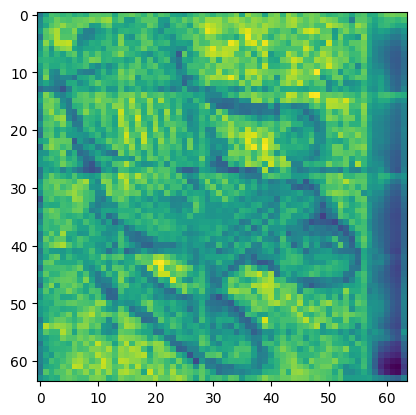

In [25]:
energy_scores =cal_energy(torch.from_numpy(q))
plt.imshow(energy_scores.reshape(64,64))
print(energy_scores.shape)

In [16]:
ori_attn.shape
re_cal_attn.shape

NameError: name 're_cal_attn' is not defined

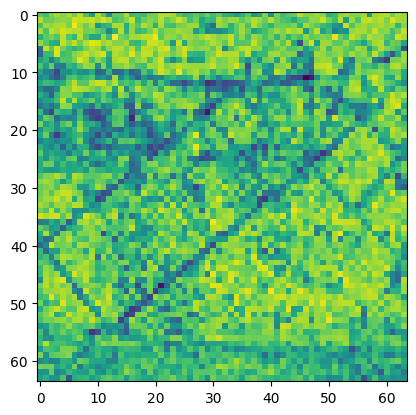

In [ ]:
plt.imshow(energy_scores.reshape(64,64))